In [3]:
import random
import numpy
import pandas
import joblib
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from typing import Any

In [4]:
USE_ROC_AUC: bool = True

In [5]:
# Define random seeds for reproducibility
SEED: int = 42
random.seed(SEED)
numpy.random.seed(SEED)

In [6]:
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

In [7]:
def load_model_package(filepath: str) -> dict[str, Any]:
    return joblib.load(filepath)

In [8]:
def apply_proportional_noise(
        X_test: pandas.DataFrame,
        train_std: pandas.Series,
        noise_fraction: float,
        mean_shift_fraction: float,
        continuous_cols: list[str]) -> pandas.DataFrame:
    """
    Adds Gaussian noise to the test data, but ONLY to the specified continuous variables,
    proportional to the standard deviation of the training data.
    noise_fraction: from 0.0 to 1.0 (0% - 100%)
    """
    if numpy.isclose(noise_fraction, 0.0, rtol=1e-09, atol=1e-09):
        return X_test.copy()

    # Create a copy of the test data to avoid modifying the original
    X_test_ood: pandas.DataFrame = X_test.copy()

    # Iterate only over the continuous columns
    for col in continuous_cols:
        # Safety check: is the column in the test data and in the std series?
        if col in X_test_ood.columns and col in train_std.index:
            std_val: float = train_std[col]

            # Mean shift (Systematic Mean Shift / Covariate Shift)
            if not numpy.isclose(mean_shift_fraction, 0.0):
                shift_amount: float = mean_shift_fraction * std_val
                # Add the noise to the column
                X_test_ood[col] += shift_amount

            # Add noise (Measurement Noise)
            if not numpy.isclose(noise_fraction, 0.0):
                # Generate noise specifically for this column
                noise: numpy.ndarray = numpy.random.normal(
                    loc=0.0,
                    scale=noise_fraction * std_val,
                    size=len(X_test_ood)
                )
                # Add the noise to the column
                X_test_ood[col] += noise

    return X_test_ood

In [9]:
def apply_dummy_noise(
        X_test: pandas.DataFrame,
        noise_fraction: float,
        dummy_cols: list[str]) -> pandas.DataFrame:
    """
    Bit-flip noise is applied to dummy (binary) variables.
    The noise_fraction specifies the probability that a given value (0 or 1) will flip.
    noise_fraction: from 0.0 to 1.0 (e.g., 0.1 = 10% chance of flipping the bit)
    """
    if numpy.isclose(noise_fraction, 0.0, rtol=1e-09, atol=1e-09):
        return X_test.copy()

    X_test_noisy: pandas.DataFrame = X_test.copy()

    for col in dummy_cols:
        # Safety check: is the column in the test data?
        if col in X_test_noisy.columns:
            # Generate a [0.0, 1.0) random array of the same length as the test data
            # Where this value is less than the noise_fraction, the mask will be True (we flip)
            flip_mask: numpy.ndarray = numpy.random.rand(len(X_test_noisy)) < noise_fraction

            # The bit-flip mathematical trick: New value = 1 - Old value
            # So, from 0 to 1 (1 - 0 = 1), and from 1 to 0 (1 - 1 = 0)
            if pandas.api.types.is_bool_dtype(X_test_noisy[col]):
                # If logical (True/False), then use the '~' (NOT) operator to flip
                X_test_noisy.loc[flip_mask, col] = ~X_test_noisy.loc[flip_mask, col]
            else:
                # If numeric (0/1), then use the mathematical '1 - x' method
                X_test_noisy.loc[flip_mask, col] = 1 - X_test_noisy.loc[flip_mask, col]

    return X_test_noisy

In [10]:
def evaluate_pipeline(model_pkg: dict[str, Any], X_noisy: pandas.DataFrame, y_true: pandas.Series) -> float:
    """
    Selects the features, scales, predicts, and returns the ROC-AUC or PR-AUC.
    """
    model: LogisticRegression = model_pkg["model"]
    scaler: StandardScaler = model_pkg["scaler"]
    features: list[str] = model_pkg["features"]

    # Select only the features relevant to the model
    X_subset: pandas.DataFrame = X_noisy[features]

    # Scale using the pre-saved scaler
    X_scaled: numpy.ndarray = scaler.transform(X_subset.to_numpy())

    # Predict probabilities
    y_pred_proba: numpy.ndarray = model.predict_proba(X_scaled)[:, 1] # Positive class probability

    if USE_ROC_AUC:
        auc_score: float = roc_auc_score(y_true, y_pred_proba)
    else:
        auc_score: float = average_precision_score(y_true, y_pred_proba)

    return auc_score

In [11]:
def plot_robustness_heatmaps(results_df: pandas.DataFrame) -> None:
    """
    Side-by-side heatmaps comparing the robustness of the two models.
    X-axis: Random noise level (Noise Level)
    Y-axis: Systematic mean shift (Mean Shift)
    Color: Test ROC-AUC or PR-AUC score
    """
    # Create a wider figure for the two subplots
    plt.figure(figsize=(16, 6))

    # Set the common color map (the 'viridis' standard and colorblind-friendly for publications)
    # Set the min/max AUC values to ensure the color scale is consistent between the two plots
    vmin = results_df["AUC"].min()
    vmax = results_df["AUC"].max()

    # 1. Multi-Objective Model Heatmap
    plt.subplot(1, 2, 1)
    df_multi = results_df[results_df["Model"] == "Multi-Objective Model"]
    # Convert the data structure to a matrix for the heatmap
    pivot_multi = df_multi.pivot(index="Mean Shift", columns="Noise Level", values="AUC")
    # Reverse the Y-axis to have positive shifts at the top
    pivot_multi = pivot_multi.sort_index(ascending=False)

    sns.heatmap(pivot_multi, cmap="viridis", vmin=vmin, vmax=vmax, annot=False,
                cbar_kws={'label': 'Test AUC'})
    plt.title("Multi-Objective Model Robustness", fontweight='bold', pad=15)
    plt.xlabel("Random Noise Level (Fraction of Train StDev)", fontweight='bold')
    plt.ylabel("Systematic Mean Shift (Fraction of Train StDev)", fontweight='bold')

    # Single-Objective Model Heatmap
    plt.subplot(1, 2, 2)
    df_single = results_df[results_df["Model"] == "Single-Objective Model"]
    pivot_single = df_single.pivot(index="Mean Shift", columns="Noise Level", values="AUC")
    pivot_single = pivot_single.sort_index(ascending=False)

    sns.heatmap(pivot_single, cmap="viridis", vmin=vmin, vmax=vmax, annot=False,
                cbar_kws={'label': 'Test AUC'})
    plt.title("Single-Objective Model Robustness", fontweight='bold', pad=15)
    plt.xlabel("Random Noise Level (Fraction of Train StDev)", fontweight='bold')
    plt.ylabel("Systematic Mean Shift (Fraction of Train StDev)", fontweight='bold')

    plt.tight_layout()
    # Save the plot for publication
    #plt.savefig("ood_robustness_heatmaps.pdf", format="pdf", bbox_inches="tight")
    plt.show()

In [12]:
CONTINUOUS_COLS: list[str] = [
    'time_in_hospital',
    'num_lab_procedures',
    'num_procedures',
    'num_medications',
    'number_outpatient',
    'number_emergency',
    'number_inpatient',
    'number_diagnoses',
    'total_previous_visits'
]

DUMMY_COLS: list[str] = [
    'acarbose_No', 'diag_1_Injury', 'race_Other', 'rosiglitazone_Up', 'chlorpropamide_No', 'chlorpropamide_Up', 'age_[80-90)', 'metformin_Up', 'nateglinide_No', 'diag_2_Other', 'glyburide-metformin_Up', 'diabetesMed_Yes', 'miglitol_Up', 'metformin_No', 'acarbose_Up', 'pioglitazone_Steady', 'acarbose_Steady', 'diag_2_Neoplasms', 'repaglinide_Up', 'age_[50-60)', 'diag_1_Respiratory', 'age_[70-80)', 'repaglinide_No', 'metformin_Steady', 'miglitol_No', 'age_[10-20)', 'tolazamide_Up', 'diag_2_Respiratory', 'nateglinide_Up', 'insulin_Steady', 'tolbutamide_Steady', 'insulin_No', 'discharge_disposition_id', 'pioglitazone_No', 'acetohexamide_Steady', 'gender_Unknown/Invalid', 'diag_3_Genitourinary', 'troglitazone_Steady', 'nateglinide_Steady', 'repaglinide_Steady', 'age_[40-50)'
]

TARGET_COL: str = "target_readmitted"
TRAIN_CSV_PATH: str = "readmit/readmit_130_hospitals_preprocessed_train_data.csv"
TEST_CSV_PATH: str = "readmit/readmit_130_hospitals_preprocessed_test_data.csv"

SINGLE_OBJECTIVE_MODEL_PATH: str = "readmit/single_objective_model_package.joblib"
MULTI_OBJECTIVE_MODEL_PATH: str = "readmit/multi_objective_model_package.joblib"

# CONTINUOUS_COLS: list[str] = [
#    'Pregnancies',
#    'Glucose',
#    'BloodPressure',
#    'SkinThickness',
#    'Insulin',
#    'BMI',
#    'DiabetesPedigreeFunction',
#    'Age'
#]

#TARGET_COL: str = "Outcome"
#TRAIN_CSV_PATH: str = "diabetes/diabetes_preprocessed_train_data.csv"
#TEST_CSV_PATH: str = "diabetes/diabetes_preprocessed_test_data.csv"

df_train: pandas.DataFrame = pandas.read_csv(TRAIN_CSV_PATH)
df_test: pandas.DataFrame = pandas.read_csv(TEST_CSV_PATH)

# Feature and Target separation
X_train: pandas.DataFrame = df_train.drop(columns=[TARGET_COL])
X_test: pandas.DataFrame = df_test.drop(columns=[TARGET_COL])
y_test: pandas.Series = df_test[TARGET_COL]

# Load the models
multi_pkg: dict[str, Any] = load_model_package(MULTI_OBJECTIVE_MODEL_PATH)
single_pkg: dict[str, Any] = load_model_package(SINGLE_OBJECTIVE_MODEL_PATH)

print("Multi-objective model features count:", len(multi_pkg["features"]))
print("Single-objective model features count:", len(single_pkg["features"]))

# Calculate the standard deviation of the training set for noise injection
train_std: pandas.Series = X_train.std()

# Store the results for plotting
results: list[dict[str, Any]] = []

# Noise levels: from 0.0 to 1.0 with 0.1 steps (0%, 10%, ..., 100%)
noise_levels: numpy.ndarray = numpy.arange(0.0, 1.1, 0.1)
shift_levels: numpy.ndarray = numpy.arange(-1.0, 1.1, 0.2)

print("Evaluation started for different noise levels...")
for shift in shift_levels:
    for noise in noise_levels:
        clean_shift: float = round(shift, 2)
        clean_noise: float = round(noise, 2)

        # Add noise to the test data (based on the training std)
        X_test_ood: pandas.DataFrame = apply_proportional_noise(X_test, train_std, clean_noise, clean_shift, CONTINUOUS_COLS)

        # Evaluate the Multi-objective model
        auc_multi: float = evaluate_pipeline(multi_pkg, X_test_ood, y_test)
        results.append({
            "Noise Level": clean_noise,
            "Mean Shift": clean_shift,
            "AUC": auc_multi,
            "Model": "Multi-Objective Model"
        })

        # Evaluate the Single-objective model
        auc_single: float = evaluate_pipeline(single_pkg, X_test_ood, y_test)
        results.append({
            "Noise Level": clean_noise,
            "Mean Shift": clean_shift,
            "AUC": auc_single,
            "Model": "Single-Objective Model"
        })

        print(f"  - Shift: {clean_shift:5.2f} | Noise: {clean_noise:4.2f} | Multi AUC: {auc_multi:.4f} | Single AUC: {auc_single:.4f}")

# DataFrame generation from the results
results_df: pandas.DataFrame = pandas.DataFrame(results)

Multi-objective model features count: 33
Single-objective model features count: 44
Evaluation started for different noise levels...
  - Shift: -1.00 | Noise: 0.00 | Multi AUC: 0.6421 | Single AUC: 0.6420
  - Shift: -1.00 | Noise: 0.10 | Multi AUC: 0.6422 | Single AUC: 0.6422
  - Shift: -1.00 | Noise: 0.20 | Multi AUC: 0.6397 | Single AUC: 0.6397
  - Shift: -1.00 | Noise: 0.30 | Multi AUC: 0.6371 | Single AUC: 0.6371
  - Shift: -1.00 | Noise: 0.40 | Multi AUC: 0.6324 | Single AUC: 0.6324
  - Shift: -1.00 | Noise: 0.50 | Multi AUC: 0.6329 | Single AUC: 0.6329
  - Shift: -1.00 | Noise: 0.60 | Multi AUC: 0.6263 | Single AUC: 0.6263
  - Shift: -1.00 | Noise: 0.70 | Multi AUC: 0.6287 | Single AUC: 0.6288
  - Shift: -1.00 | Noise: 0.80 | Multi AUC: 0.6215 | Single AUC: 0.6216
  - Shift: -1.00 | Noise: 0.90 | Multi AUC: 0.6165 | Single AUC: 0.6165
  - Shift: -1.00 | Noise: 1.00 | Multi AUC: 0.6138 | Single AUC: 0.6138
  - Shift: -0.80 | Noise: 0.00 | Multi AUC: 0.6421 | Single AUC: 0.6420
  - 

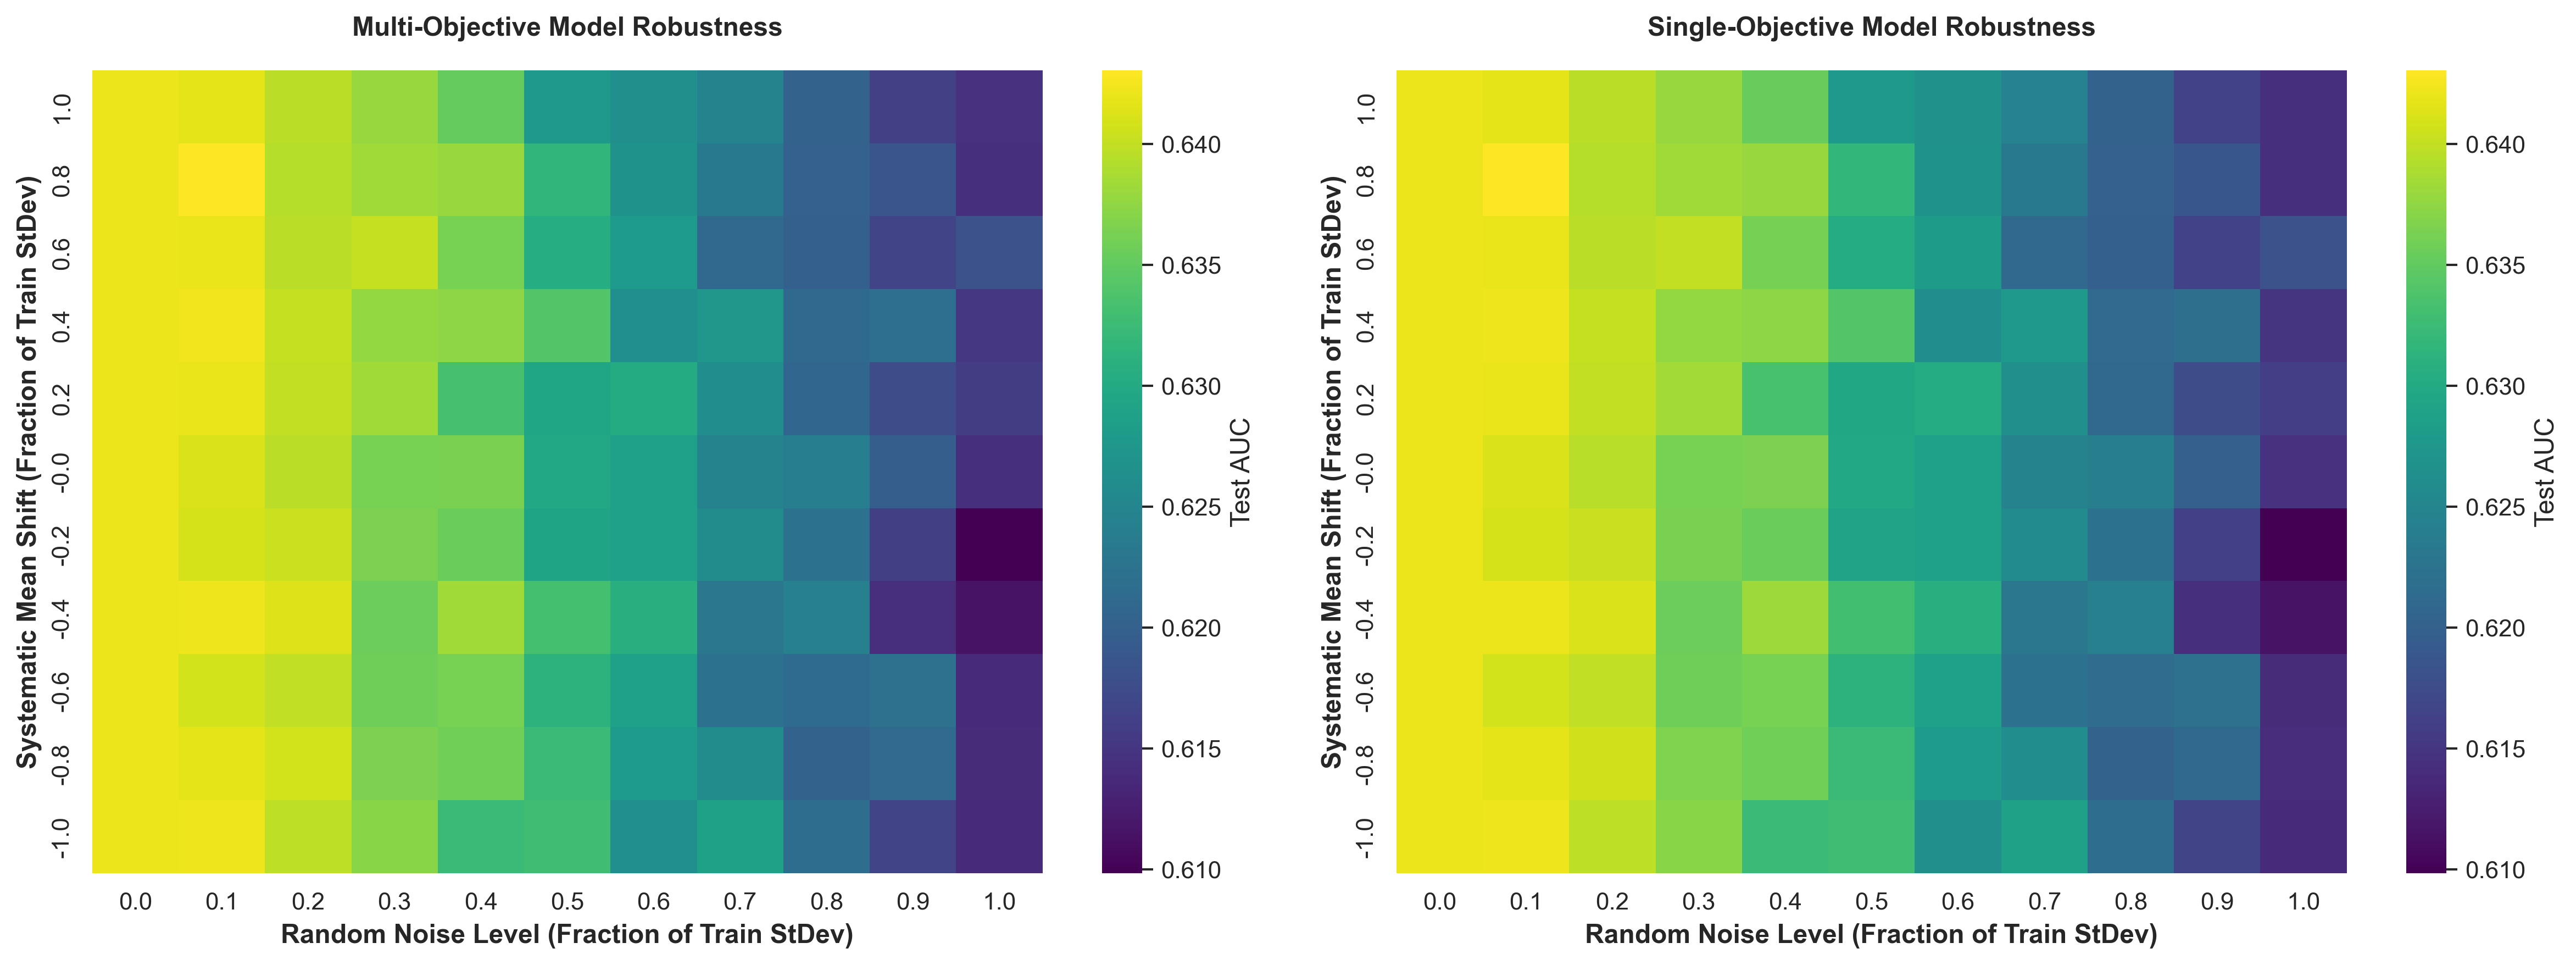

In [13]:
# Side-by-side heatmaps (noise and shift on continuous variables)
plot_robustness_heatmaps(results_df)

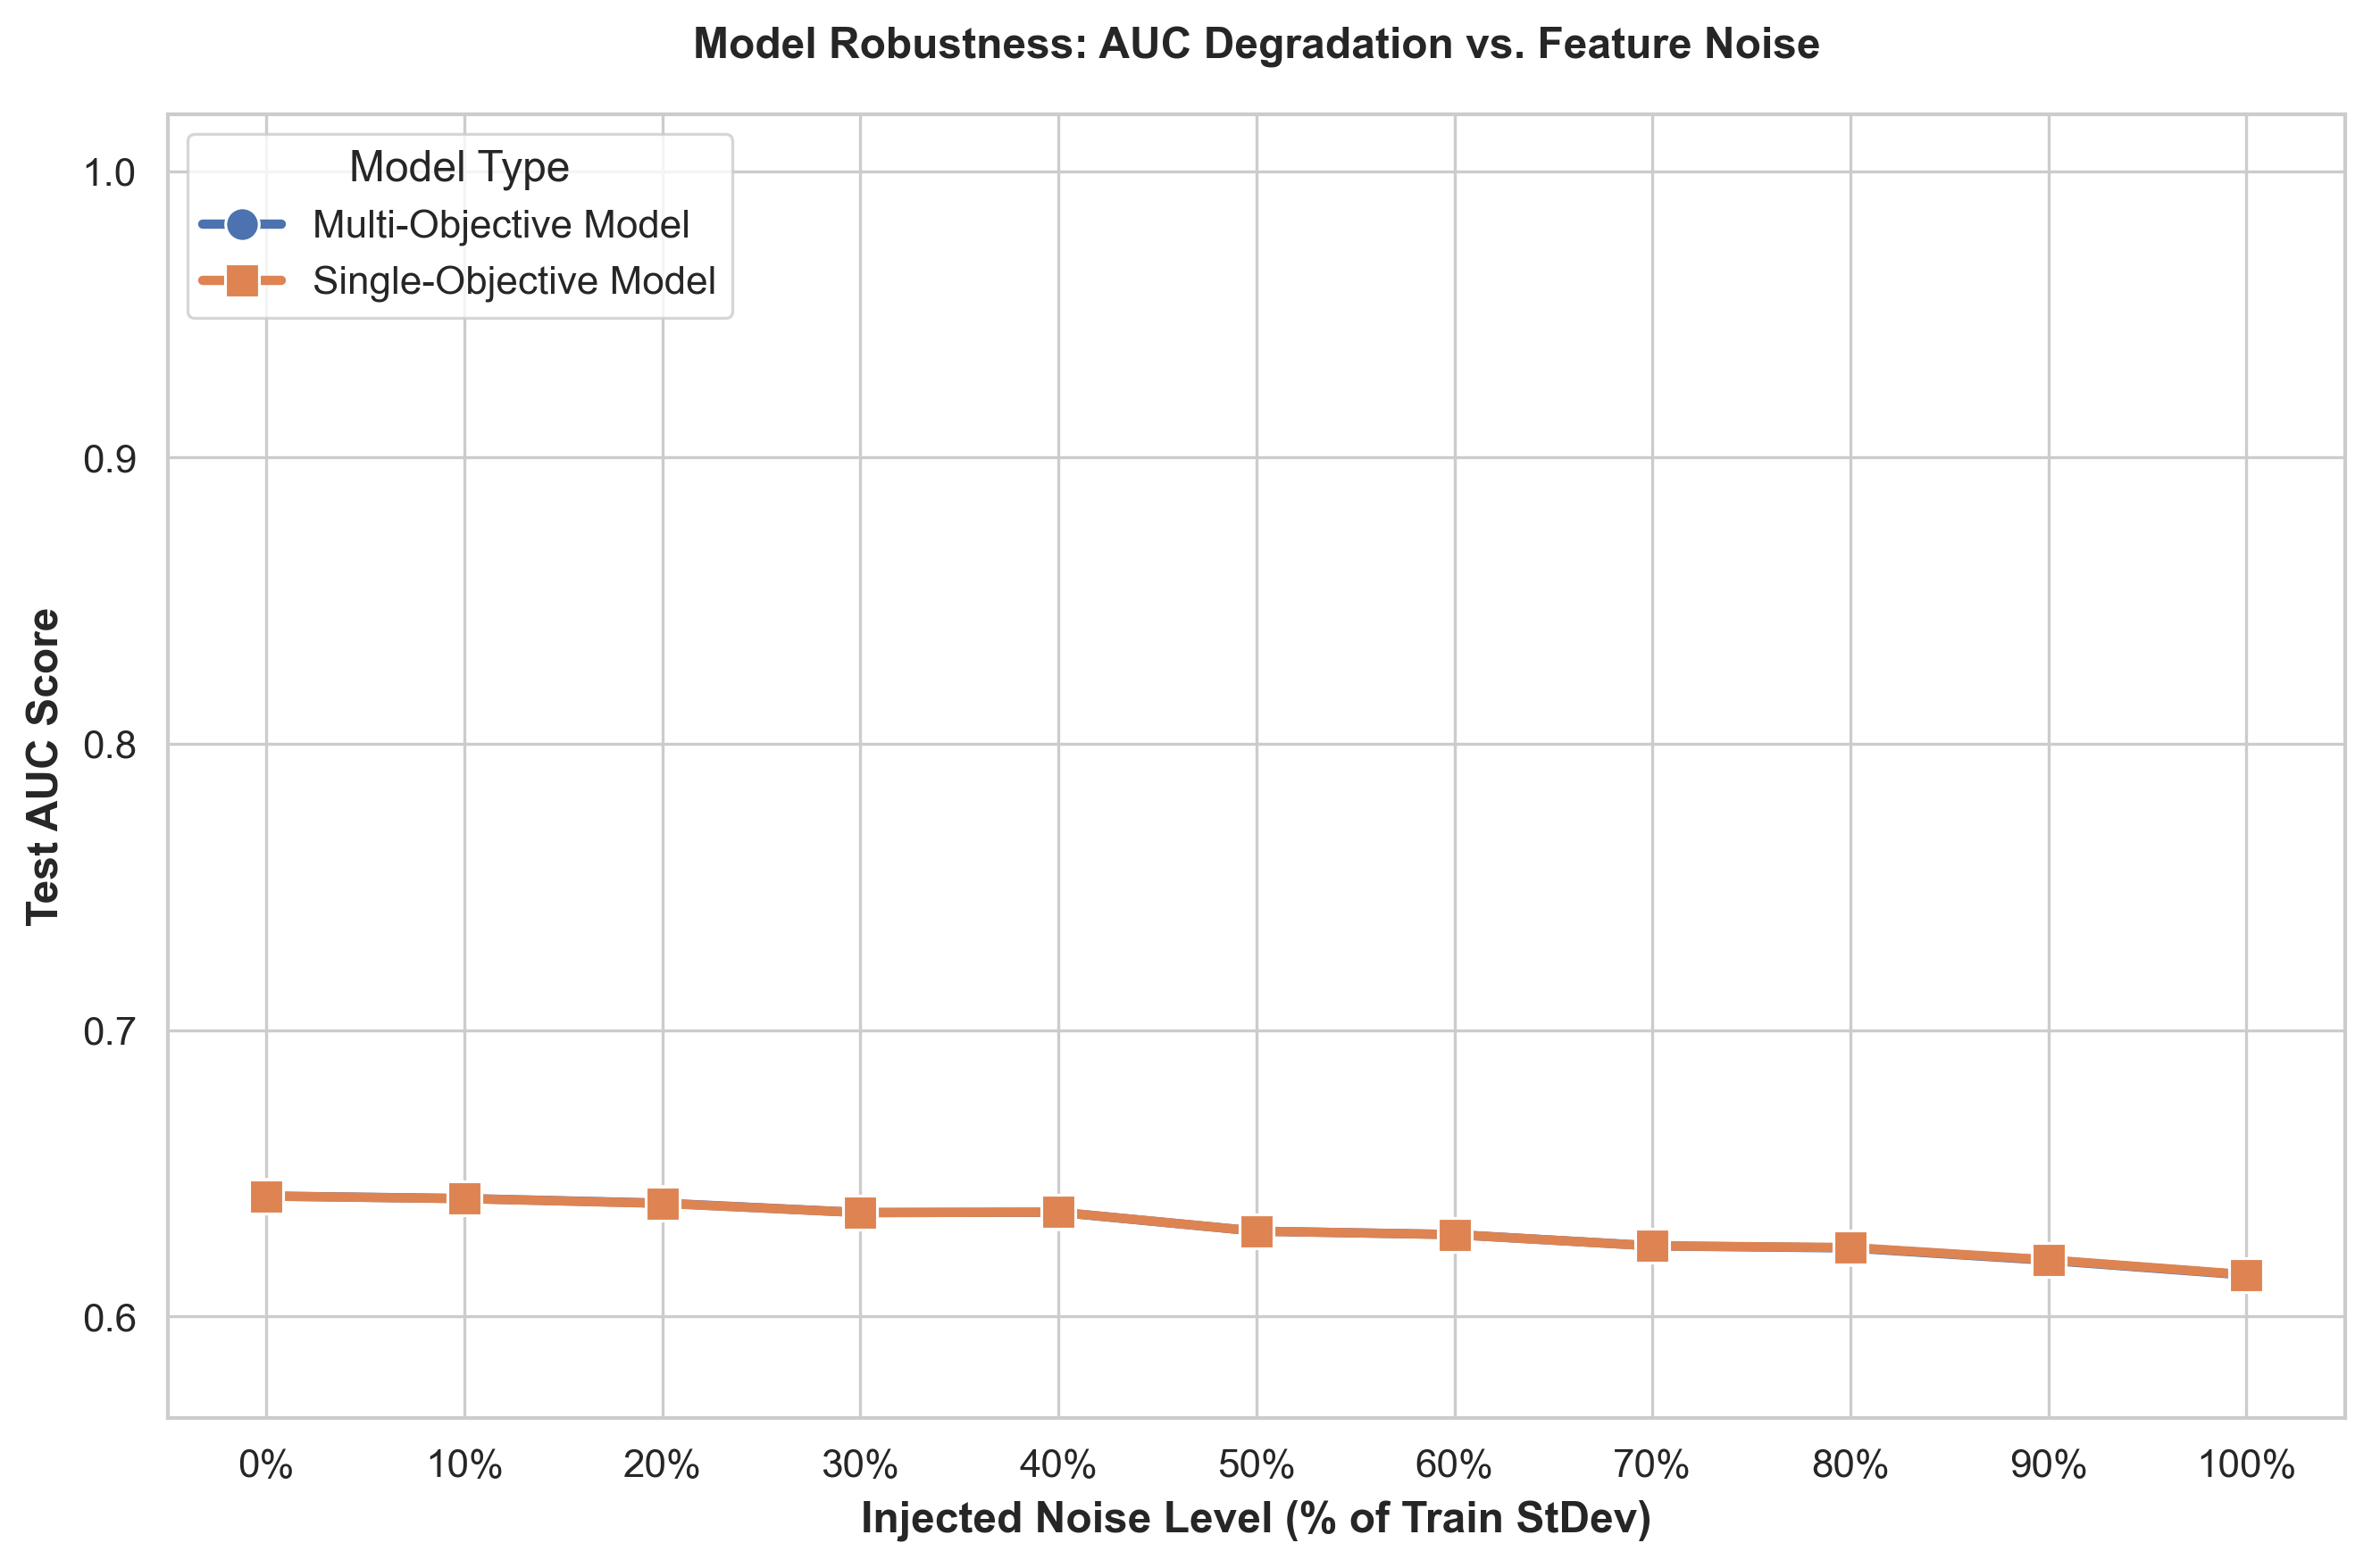

In [14]:
# Baseline shift (Mean Shift = 0.0)
df_baseline_shift: pandas.DataFrame = results_df[results_df["Mean Shift"] == 0.0].copy()

plt.figure(figsize=(9, 6))
ax: matplotlib.axes.Axes = sns.lineplot(
    data=df_baseline_shift, # Csak a 0.0 eltolású adatokat kapja meg
    x="Noise Level",
    y="AUC",
    hue="Model",
    style="Model",
    markers=["o", "s"],
    dashes=False,
    linewidth=2.5,
    markersize=9
)

plt.xticks(noise_levels, [f"{int(n*100)}%" for n in noise_levels])

plt.title("Model Robustness: AUC Degradation vs. Feature Noise", fontweight='bold', pad=15)
plt.xlabel("Injected Noise Level (% of Train StDev)", fontweight='bold')
plt.ylabel("Test AUC Score", fontweight='bold')
plt.ylim(max(0.0, df_baseline_shift["AUC"].min() - 0.05), 1.02)
plt.legend(title="Model Type", loc='upper left')
plt.tight_layout()

#plt.savefig("model_robustness_noise_1d.pdf", format="pdf", bbox_inches="tight")
plt.show()

Evaluation started for Dummy Variable (Bit-flip) noise only...
  - Bit-flip Probability:   0% | Multi AUC: 0.6421 | Single AUC: 0.6420
  - Bit-flip Probability:  10% | Multi AUC: 0.5473 | Single AUC: 0.5291
  - Bit-flip Probability:  20% | Multi AUC: 0.5301 | Single AUC: 0.5165
  - Bit-flip Probability:  30% | Multi AUC: 0.5364 | Single AUC: 0.5242
  - Bit-flip Probability:  40% | Multi AUC: 0.5239 | Single AUC: 0.5133
  - Bit-flip Probability:  50% | Multi AUC: 0.5189 | Single AUC: 0.5032
  - Bit-flip Probability:  60% | Multi AUC: 0.5200 | Single AUC: 0.5095
  - Bit-flip Probability:  70% | Multi AUC: 0.5199 | Single AUC: 0.5045
  - Bit-flip Probability:  80% | Multi AUC: 0.5280 | Single AUC: 0.5178
  - Bit-flip Probability:  90% | Multi AUC: 0.5365 | Single AUC: 0.5273
  - Bit-flip Probability: 100% | Multi AUC: 0.5736 | Single AUC: 0.5727


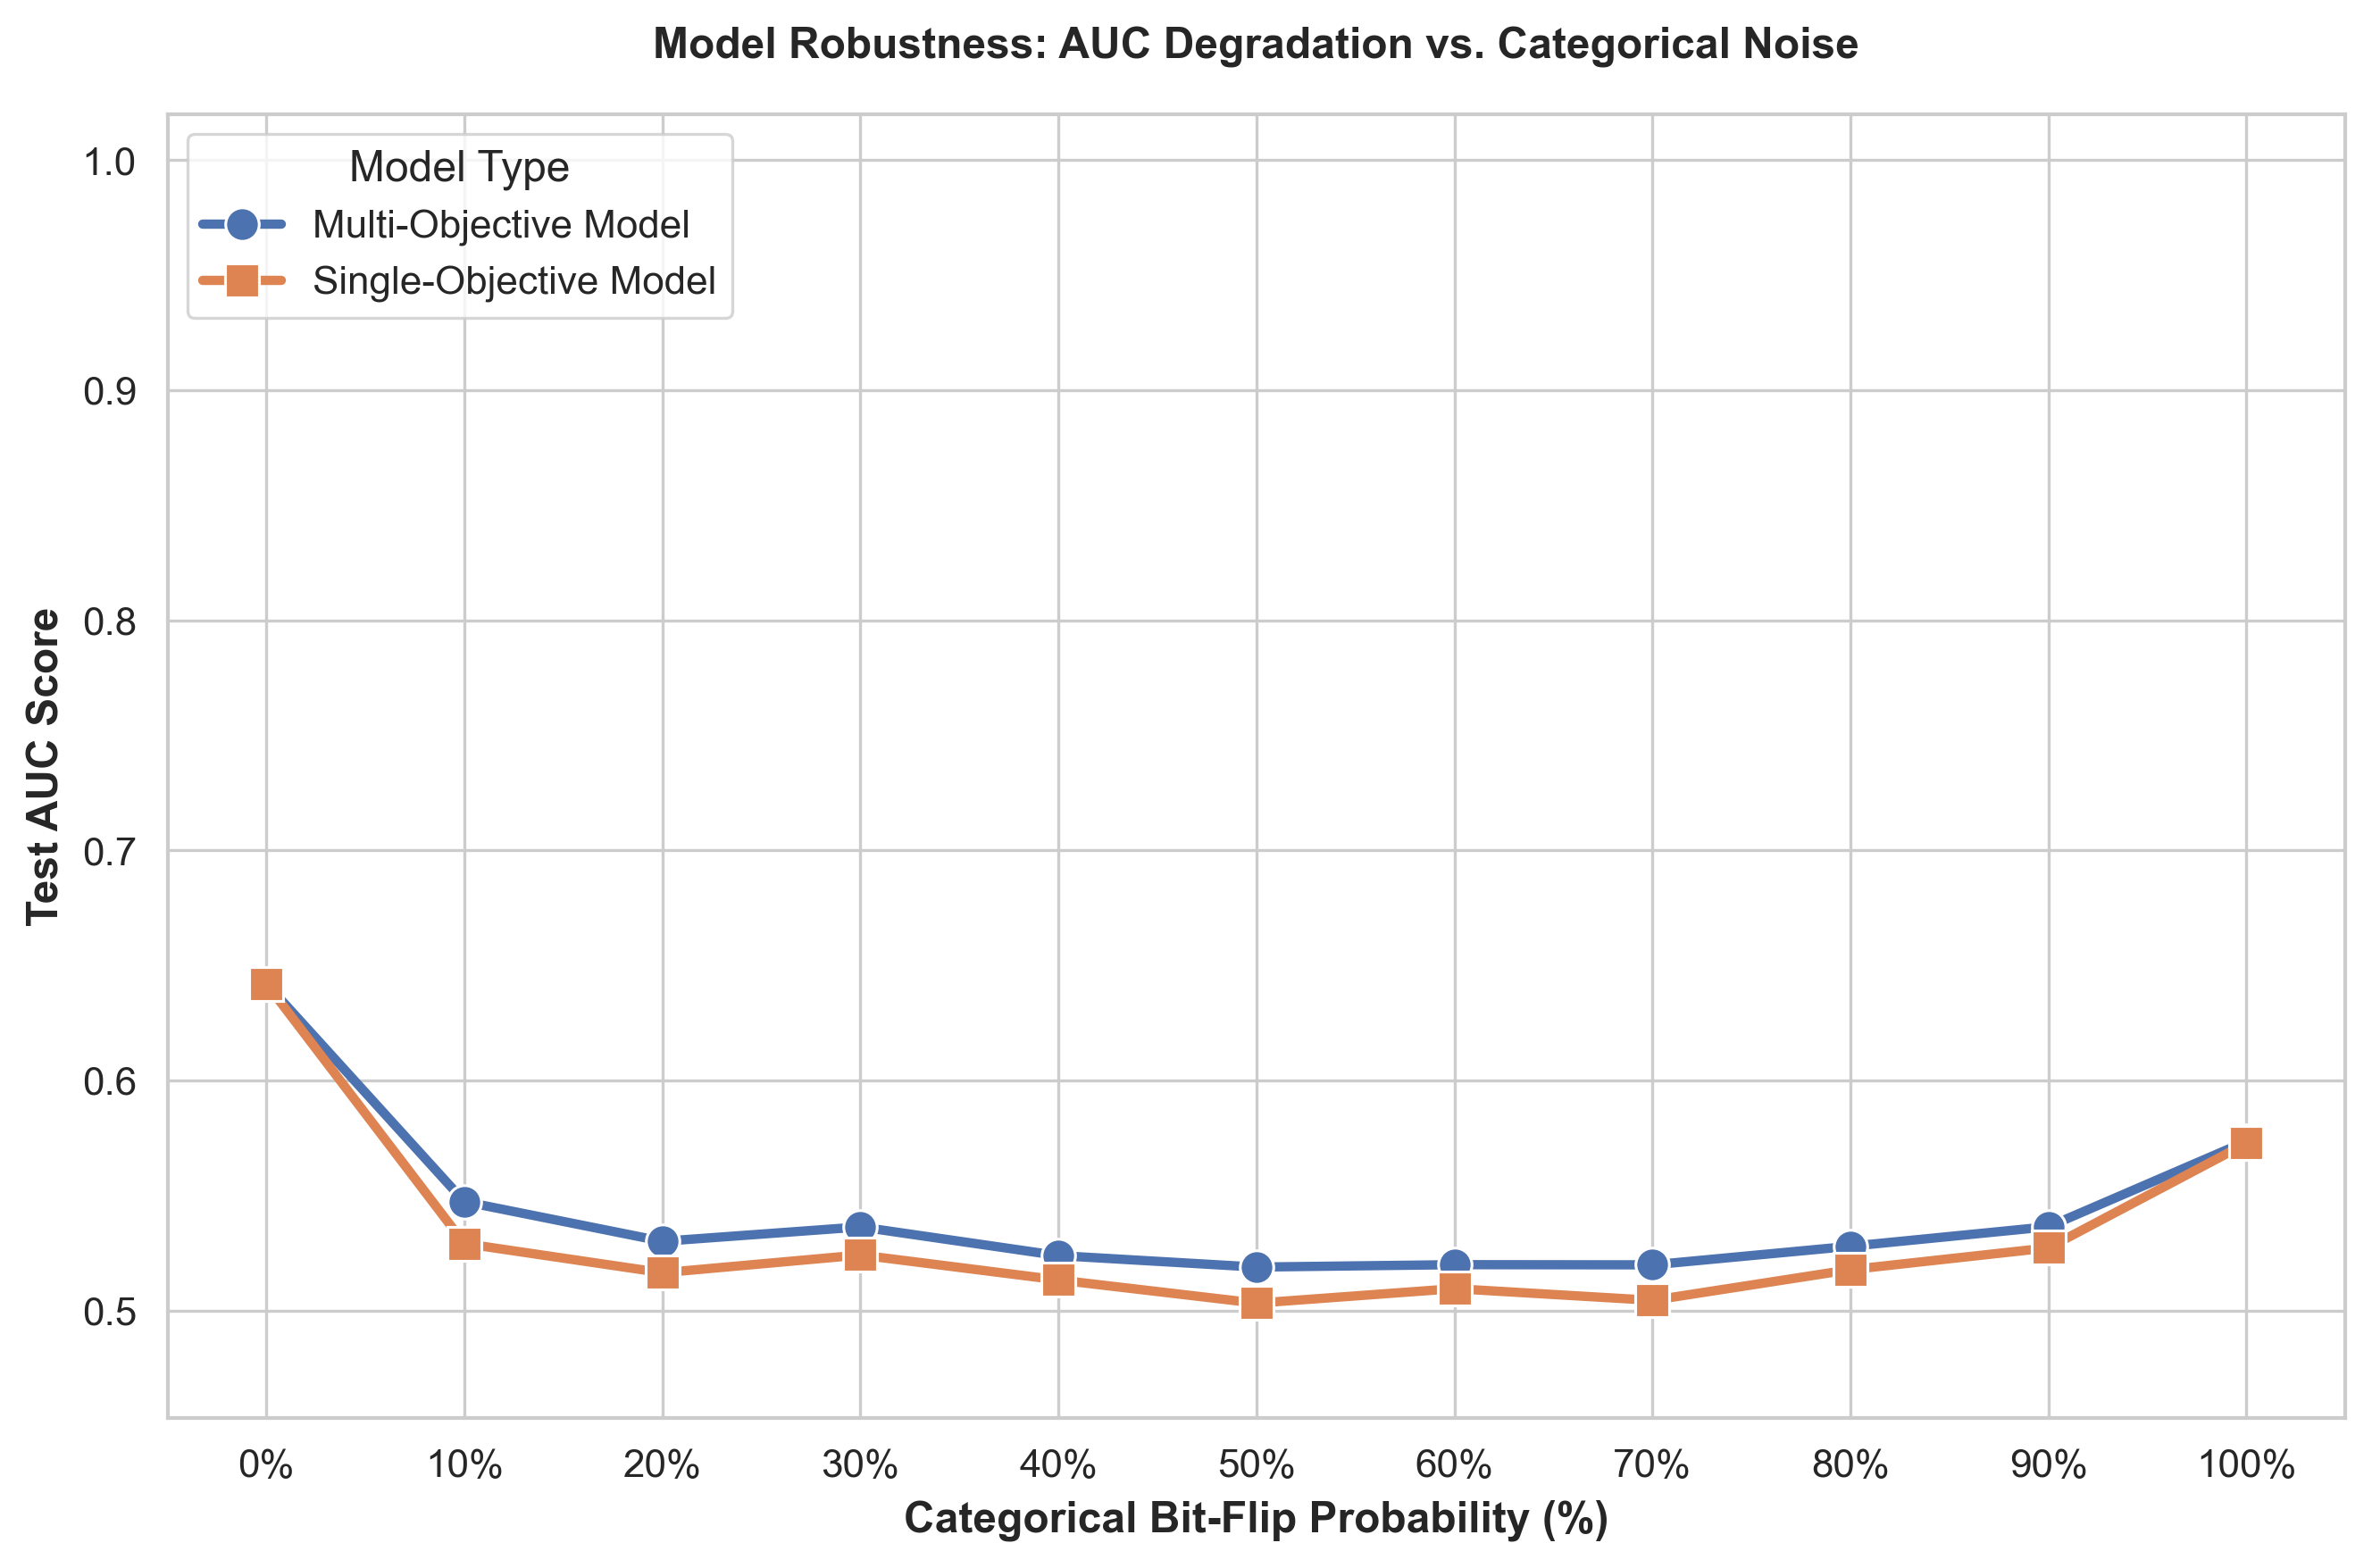

In [15]:
dummy_results: list[dict[str, Any]] = []
noise_levels: numpy.ndarray = numpy.arange(0.0, 1.1, 0.1)

print("Evaluation started for Dummy Variable (Bit-flip) noise only...")
for noise in noise_levels:
    clean_noise: float = round(noise, 2)

    X_test_dummy_noisy: pandas.DataFrame = apply_dummy_noise(
        X_test, clean_noise, DUMMY_COLS
    )

    auc_multi: float = evaluate_pipeline(multi_pkg, X_test_dummy_noisy, y_test)
    dummy_results.append({
        "Noise Level": clean_noise,
        "AUC": auc_multi,
        "Model": "Multi-Objective Model"
    })

    auc_single: float = evaluate_pipeline(single_pkg, X_test_dummy_noisy, y_test)
    dummy_results.append({
        "Noise Level": clean_noise,
        "AUC": auc_single,
        "Model": "Single-Objective Model"
    })

    print(f"  - Bit-flip Probability: {clean_noise*100:3.0f}% | Multi AUC: {auc_multi:.4f} | Single AUC: {auc_single:.4f}")

df_dummy_results: pandas.DataFrame = pandas.DataFrame(dummy_results)

plt.figure(figsize=(9, 6))

ax: matplotlib.axes.Axes = sns.lineplot(
    data=df_dummy_results,
    x="Noise Level",
    y="AUC",
    hue="Model",
    style="Model",
    markers=["o", "s"],
    dashes=False,
    linewidth=2.5,
    markersize=9
)

plt.xticks(noise_levels, [f"{int(n*100)}%" for n in noise_levels])

plt.title("Model Robustness: AUC Degradation vs. Categorical Noise", fontweight='bold', pad=15)
plt.xlabel("Categorical Bit-Flip Probability (%)", fontweight='bold')
plt.ylabel("Test AUC Score", fontweight='bold')

plt.ylim(max(0.0, df_dummy_results["AUC"].min() - 0.05), 1.02)

plt.legend(title="Model Type", loc='upper left')
plt.tight_layout()

# plt.savefig("model_robustness_categorical_noise.pdf", format="pdf", bbox_inches="tight")
plt.show()